# D08 · Factorial questions and the meaning of an interaction

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PD06](../../curriculum/papers/design.md#pd06).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** What comparison is needed to distinguish an interaction from a main effect or a sampling difference?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

A factorial design crosses factors so that each combination can be compared. Suppose factor A is task difficulty and factor B is cue type. The four condition means can answer several distinct questions: the average effect of difficulty, the average effect of cue, and whether the difficulty effect depends on cue. The last is an interaction. An interaction is not established because one condition has a significant simple effect and another does not; the difference between effects must itself be tested.

This notebook uses four exact condition means in order A0B0, A0B1, A1B0, A1B1: one, three, two, eight. The cue effect is two units at A0 and six units at A1. Their difference is four units. The average A effect is three and the average B effect is four when the four cells are equally weighted. If groups or cells are imbalanced, an observed marginal difference can depend on cell weights; state the intended averaging rule instead of letting the table determine it accidentally.

Coding changes coefficient interpretation. With zero/one coding and an interaction column, the A coefficient describes the A effect when B equals zero. It is not the A effect averaged across B. Centering both binary columns at 0.5 changes that coefficient to the equally weighted average effect, while leaving the fitted cell means identical. The interaction coefficient remains the difference of differences. We verify these statements algebraically using a noiseless design so no significance threshold obscures the meaning.

A factorial label does not guarantee an unconfounded experiment. If one condition always appears last, fatigue can mimic its effect. If combinations are absent, some contrasts may not be estimable. If the same people perform all cells, their repeated outcomes must be modeled as dependent. Randomizing or counterbalancing order and retaining cell labels is part of the design. AI may construct a formally correct matrix that ignores the assignment and measurement hierarchy, so ask it to show the contingency table and unit of analysis first.

Name the four cell means and calculate the difference of differences before fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
A = np.array([0., 0., 1., 1.]); B = np.array([0., 1., 0., 1.])
y = np.array([1., 3., 2., 8.])
X = np.column_stack([np.ones(4), A, B, A*B])
beta = np.linalg.solve(X, y)
interaction = (y[3]-y[2]) - (y[1]-y[0])
average_A = (y[2]+y[3]-y[0]-y[1])/2
average_B = (y[1]+y[3]-y[0]-y[2])/2
assert np.allclose(beta, [1, 1, 2, 4])
assert np.allclose([interaction, average_A, average_B], [4, 3, 4])
print(pd.DataFrame({'A':A,'B':B,'mean':y}))
print('0/1-coded coefficients:', beta)

     A    B  mean
0  0.0  0.0   1.0
1  0.0  1.0   3.0
2  1.0  0.0   2.0
3  1.0  1.0   8.0
0/1-coded coefficients: [1. 1. 2. 4.]


Centering changes coefficient meanings, not fitted condition means.

Centered coefficients: [3.5 3.  4.  4. ]


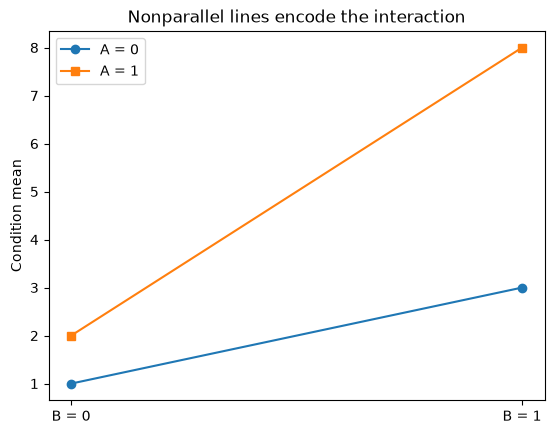

In [2]:
Ac, Bc = A-.5, B-.5
Xc = np.column_stack([np.ones(4), Ac, Bc, Ac*Bc])
bc = np.linalg.solve(Xc, y)
assert np.allclose(Xc @ bc, X @ beta)
assert np.allclose(bc[1:], [3, 4, 4])
print('Centered coefficients:', bc)
plt.plot([0,1], y[:2], 'o-', label='A = 0')
plt.plot([0,1], y[2:], 's-', label='A = 1')
plt.xticks([0,1], ['B = 0','B = 1']); plt.ylabel('Condition mean')
plt.title('Nonparallel lines encode the interaction'); plt.legend(); plt.show()
assert np.linalg.matrix_rank(X[:3]) < X.shape[1]

## Supervise the AI, then transfer the idea

**AI prompt:** “Build a cell-mean table before any regression. Explain the simple effects, equal-cell marginal effects, and interaction. Predict what centering changes. Give no more than 15 lines per operation and never infer an interaction by comparing two significance labels.”

**Deliberate mistake:** call beta_A=1 the average A effect. Repair it by naming the reference B level or using the contrast that averages both B levels. Then remove A1B1 and identify the lost degree of information. For real fMRI, write the contrast in the exact order of convolved condition columns, including zeros for nuisance and run constants. Decide whether unequal cells reflect design, missing trials, or errors; those explanations may require different treatment. Deliver a figure of simple effects and two equivalent parameterizations with correctly translated contrasts.

## Answer key — read after your own explanation

The interaction is four: the B effect increases from two to six. The equal-cell average A effect is three, not the 0/1-coded A coefficient of one. Centered A and B coefficients are three and four; fitted means are unchanged. Four noiseless cells and four parameters provide no residual degrees of freedom for uncertainty estimation; the calculation teaches estimands and coding, not a valid t test. Repeated observations must supply appropriately modeled uncertainty.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [MIT 9.63, Factor design I, Factorial design, ANOVA lecture list](https://ocw.mit.edu/courses/9-63-laboratory-in-visual-cognition-fall-2009/pages/lecture-notes/); [Berkeley hypothesis tests and GLM](https://github.com/bic-berkeley/psych-214-fall-2016/blob/ec44652addc92091183456fa04fcd41dca0e172e/hypothesis_tests.rst). See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Reopen [PD06](../../curriculum/papers/design.md#pd06) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
